In [ ]:
import requests
import pandas as pd
import time

BASE = "https://api.elections.kalshi.com/trade-api/v2"

events = {
    "NATGAS": "KXNATGAS15M-26SEP150945",
    "WTI": "KXWTI15M-26SEP150945"
}

# ------------------------------------
# 1. GET ALL MARKETS INSIDE EACH EVENT
# ------------------------------------

event_markets = {}

for name, event_ticker in events.items():

    r = requests.get(
        f"{BASE}/markets",
        params={
            "event_ticker": event_ticker,
            "limit": 100
        }
    )
    r.raise_for_status()

    markets = r.json()["markets"]
    event_markets[name] = markets

    print("\n" + "="*70)
    print(name, "-", event_ticker)
    print("="*70)

    for m in markets:
        print("Ticker:", m["ticker"])
        print("YES:", m.get("yes_sub_title"))
        print("NO:", m.get("no_sub_title"))
        print("Floor strike:", m.get("floor_strike"))
        print("Cap strike:", m.get("cap_strike"))
        print()


NATGAS - KXNATGAS15M-26SEP150945
Ticker: KXNATGAS15M-26SEP150945-45
YES: Target Price: $3.07028
NO: Target price: TBD
Floor strike: 3.07028
Cap strike: None


WTI - KXWTI15M-26SEP150945
Ticker: KXWTI15M-26SEP150945-45
YES: Target Price: $98.53
NO: Target price: TBD
Floor strike: 98.53
Cap strike: None



In [ ]:
import requests
import pandas as pd

BASE = "https://api.elections.kalshi.com/trade-api/v2"

markets = {
    "NATGAS": "KXNATGAS15M-26SEP150945-45",
    "WTI": "KXWTI15M-26SEP150945-45"
}

rows = []

for asset, ticker in markets.items():

    # Get market information
    r = requests.get(f"{BASE}/markets/{ticker}")
    r.raise_for_status()
    m = r.json()["market"]

    start = int(pd.Timestamp(m["open_time"]).timestamp())
    end = int(pd.Timestamp(m["close_time"]).timestamp())

    # Get 1-minute candlesticks
    r = requests.get(
        f"{BASE}/markets/candlesticks",
        params={
            "market_tickers": ticker,
            "start_ts": start,
            "end_ts": end,
            "period_interval": 1
        }
    )

    r.raise_for_status()
    data = r.json()

    for market_data in data.get("markets", []):

        for c in market_data.get("candlesticks", []):

            bid = c.get("yes_bid", {}).get("close_dollars")
            ask = c.get("yes_ask", {}).get("close_dollars")

            bid = float(bid) if bid is not None else None
            ask = float(ask) if ask is not None else None

            rows.append({
                "asset": asset,
                "timestamp": pd.to_datetime(
                    c["end_period_ts"],
                    unit="s",
                    utc=True
                ),
                "yes_bid": bid,
                "yes_ask": ask,
                "no_bid": 1 - ask if ask is not None else None,
                "no_ask": 1 - bid if bid is not None else None,
                "yes_mid": (
                    (bid + ask) / 2
                    if bid is not None and ask is not None
                    else None
                )
            })


df = pd.DataFrame(rows)

df = df.sort_values(
    ["timestamp", "asset"]
).reset_index(drop=True)

display(df)

print("\nObservations:")
print(df.groupby("asset").size())

,asset,timestamp,yes_bid,yes_ask,no_bid,no_ask,yes_mid
0,NATGAS,2026-09-15 13:31:00+00:00,0.520,0.550,0.450,0.480,0.5350
1,WTI,2026-09-15 13:31:00+00:00,0.760,0.770,0.230,0.240,0.7650
2,NATGAS,2026-09-15 13:32:00+00:00,0.620,0.680,0.320,0.380,0.6500
3,WTI,2026-09-15 13:32:00+00:00,0.840,0.850,0.150,0.160,0.8450
4,NATGAS,2026-09-15 13:33:00+00:00,0.650,0.690,0.310,0.350,0.6700
5,WTI,2026-09-15 13:33:00+00:00,0.926,0.928,0.072,0.074,0.9270
6,NATGAS,2026-09-15 13:34:00+00:00,0.620,0.630,0.370,0.380,0.6250
7,WTI,2026-09-15 13:34:00+00:00,0.933,0.934,0.066,0.067,0.9335
8,NATGAS,2026-09-15 13:35:00+00:00,0.690,0.730,0.270,0.310,0.7100
9,WTI,2026-09-15 13:35:00+00:00,0.950,0.955,0.045,0.050,0.9525



Observations:
asset
NATGAS    15
WTI       15
dtype: int64


In [ ]:
prices = df.pivot(
    index="timestamp",
    columns="asset",
    values="yes_mid"
).dropna()

prices

asset,NATGAS,WTI
timestamp,,
2026-09-15 13:31:00+00:00,0.535,0.7650
2026-09-15 13:32:00+00:00,0.650,0.8450
2026-09-15 13:33:00+00:00,0.670,0.9270
2026-09-15 13:34:00+00:00,0.625,0.9335
2026-09-15 13:35:00+00:00,0.710,0.9525
2026-09-15 13:36:00+00:00,0.560,0.8900
2026-09-15 13:37:00+00:00,0.495,0.8350
2026-09-15 13:38:00+00:00,0.510,0.9225
2026-09-15 13:39:00+00:00,0.190,0.9645


In [ ]:
covariance = prices["NATGAS"].cov(prices["WTI"])

print("Covariance:", covariance)

Covariance: 0.003336202380952382


In [ ]:
correlation = prices["NATGAS"].corr(prices["WTI"])

print("Correlation:", correlation)

Correlation: 0.21642772291619253


In [ ]:
changes = prices.diff().dropna()

changes

asset,NATGAS,WTI
timestamp,,
2026-09-15 13:32:00+00:00,0.115,0.0800
2026-09-15 13:33:00+00:00,0.020,0.0820
2026-09-15 13:34:00+00:00,-0.045,0.0065
2026-09-15 13:35:00+00:00,0.085,0.0190
2026-09-15 13:36:00+00:00,-0.150,-0.0625
2026-09-15 13:37:00+00:00,-0.065,-0.0550
2026-09-15 13:38:00+00:00,0.015,0.0875
2026-09-15 13:39:00+00:00,-0.320,0.0420
2026-09-15 13:40:00+00:00,0.190,0.0095


In [ ]:
changes = prices.diff().dropna()

changes

asset,NATGAS,WTI
timestamp,,
2026-09-15 13:32:00+00:00,0.115,0.0800
2026-09-15 13:33:00+00:00,0.020,0.0820
2026-09-15 13:34:00+00:00,-0.045,0.0065
2026-09-15 13:35:00+00:00,0.085,0.0190
2026-09-15 13:36:00+00:00,-0.150,-0.0625
2026-09-15 13:37:00+00:00,-0.065,-0.0550
2026-09-15 13:38:00+00:00,0.015,0.0875
2026-09-15 13:39:00+00:00,-0.320,0.0420
2026-09-15 13:40:00+00:00,0.190,0.0095


In [ ]:
change_covariance = changes["NATGAS"].cov(
    changes["WTI"]
)

print("Covariance of changes:", change_covariance)

Covariance of changes: 0.000792403846153848


In [ ]:
change_correlation = changes["NATGAS"].corr(
    changes["WTI"]
)

print("Correlation of changes:", change_correlation)

Correlation of changes: 0.10748775005186059


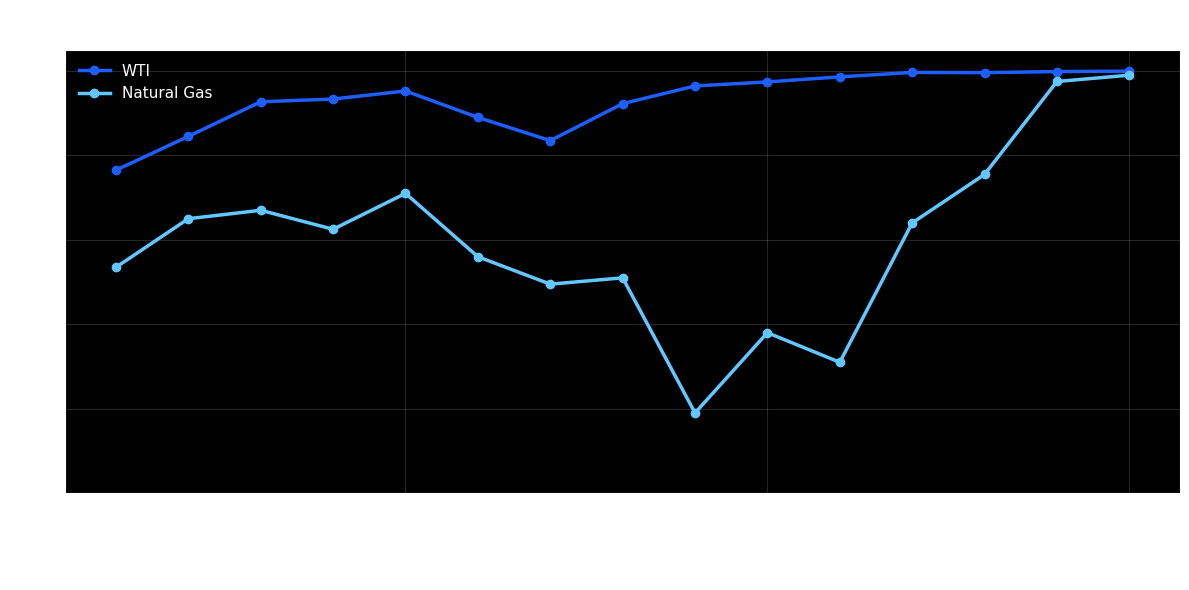

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.style.use("dark_background")

plt.plot(
    prices.index,
    prices["WTI"],
    marker="o",
    linewidth=2.5,
    color="#1E5EFF",
    label="WTI"
)

plt.plot(
    prices.index,
    prices["NATGAS"],
    marker="o",
    linewidth=2.5,
    color="#63C7FF",
    label="Natural Gas"
)

plt.title(
    "WTI vs Natural Gas — Kalshi YES Prices",
    fontsize=18,
    color="white",
    pad=15
)

plt.xlabel("Time", fontsize=12, color="white")
plt.ylabel("YES Price / Probability", fontsize=12, color="white")

plt.ylim(0, 1.05)

plt.grid(alpha=0.15)
plt.legend(frameon=False, fontsize=11)

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")

plt.tight_layout()
plt.show()

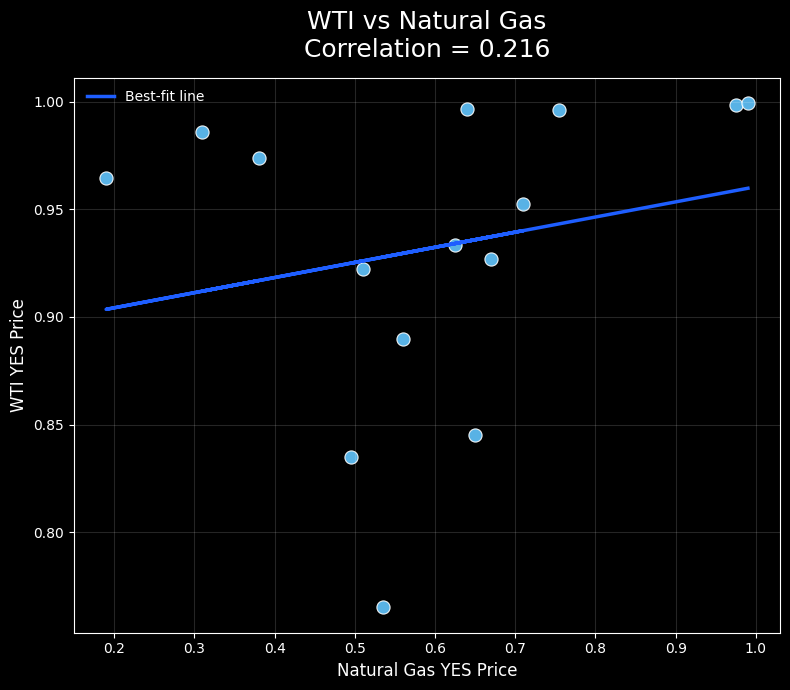

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = prices["NATGAS"]
y = prices["WTI"]

# Best-fit line
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 7))
plt.style.use("dark_background")

plt.scatter(
    x,
    y,
    s=90,
    color="#63C7FF",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9
)

plt.plot(
    x,
    m*x + b,
    color="#1E5EFF",
    linewidth=2.5,
    label="Best-fit line"
)

corr = x.corr(y)

plt.title(
    f"WTI vs Natural Gas\nCorrelation = {corr:.3f}",
    fontsize=18,
    color="white",
    pad=15
)

plt.xlabel(
    "Natural Gas YES Price",
    fontsize=12,
    color="white"
)

plt.ylabel(
    "WTI YES Price",
    fontsize=12,
    color="white"
)

plt.grid(alpha=0.15)
plt.legend(frameon=False)

plt.xticks(color="white")
plt.yticks(color="white")

plt.tight_layout()
plt.show()

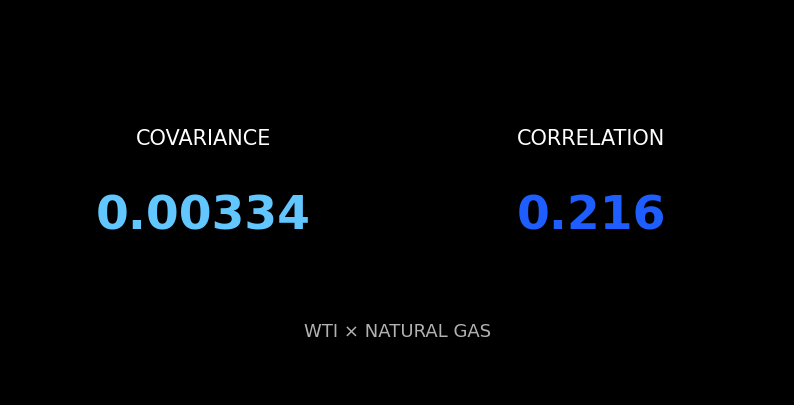

In [ ]:
import matplotlib.pyplot as plt

cov = prices["NATGAS"].cov(prices["WTI"])
corr = prices["NATGAS"].corr(prices["WTI"])

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.axis("off")

ax.text(
    0.25, 0.65,
    "COVARIANCE",
    ha="center",
    fontsize=15,
    color="white"
)

ax.text(
    0.25, 0.43,
    f"{cov:.5f}",
    ha="center",
    fontsize=34,
    fontweight="bold",
    color="#63C7FF"
)

ax.text(
    0.75, 0.65,
    "CORRELATION",
    ha="center",
    fontsize=15,
    color="white"
)

ax.text(
    0.75, 0.43,
    f"{corr:.3f}",
    ha="center",
    fontsize=34,
    fontweight="bold",
    color="#1E5EFF"
)

ax.text(
    0.5, 0.15,
    "WTI × NATURAL GAS",
    ha="center",
    fontsize=13,
    color="white",
    alpha=0.7
)

plt.show()